# Full Model

### Initialization: libraries and initial settings

In [1]:
# ----- Load libraries -----

# Built-in
using Colors, CSV, Dates, DataFrames, Distributions, FileIO, JLD2, XLSX, KernelDensity, PlotlyJS, PlotlyKaleido;
# start PlotlyKaleido
PlotlyKaleido.start()
pltjs = PlotlyJS

# Custom
include("./code/Metropolis-Within-Gibbs/MetropolisWithinGibbs.jl");
using Main.MetropolisWithinGibbs;


┌ Warning: Kaledio is not available on this system. Julia will be unable to produce any plots.
└ @ PlotlyBase C:\Users\wrc938\.julia\packages\PlotlyBase\NxSlF\src\kaleido.jl:58


### Prepare Results

In [2]:
# ----- Load results from output file -----

res           = load("$(pwd())/res_two_gap_AR2_6_obs_iis.jld2");

#create results folder
results_folder = "results_two_gap_AR2_6_obs_iis"
if !isdir(results_folder)
   mkdir(results_folder)
end
   
nDraws        = res["nDraws"];
burnin        = res["burnin"];
σʸ            = res["σʸ"]';
date          = res["date"];
data          = res["data"] .* σʸ';
distr_α       = res["distr_α"];
chain_θ_bound = res["chain_θ_bound"]; # d, Z, R, c, T, Q, λ, ρ, total
distr_par     = res["distr_par"];  # Use distr_par to get Z matrices directly
MNEMONIC      = res["MNEMONIC"];



data[ismissing.(data)] .= NaN;

par_ind  = res["par_ind"];


par_size = SizeParSsm(sum(par_ind.d),
                                 sum(sum(par_ind.Z)),
                                 sum(sum(par_ind.Z_plus)),
                                 sum(sum(par_ind.Z_minus)),
                                 sum(sum(par_ind.R)),
                                 sum(par_ind.c),
                                 sum(sum(par_ind.T)),
                                 sum(sum(par_ind.Q)),
                                 sum(sum(par_ind.Q_cov)), 
                                 sum(sum(par_ind.H)),
                                 sum(sum(par_ind.λ)),
                                 sum(sum(par_ind.ρ)),
                                 sum(par_ind.d) + sum(sum(par_ind.Z)) + sum(sum(par_ind.Z_plus)) +
                                    sum(sum(par_ind.Z_minus)) + sum(sum(par_ind.R)) +
                                    sum(par_ind.c) + sum(sum(par_ind.T)) + sum(sum(par_ind.Q)) + 
                                    sum(sum(par_ind.Q_cov)) + sum(sum(par_ind.H)) + sum(sum(par_ind.λ)) + sum(sum(par_ind.ρ)));

println(par_size);   

# ----- Set titles and scales -----

titles = ["Real GDP", "Employment", "Unemployment rate", "Inflation rate", "UoM Expected inflation", "SPF Expected inflation"];
scales = ["Pct.", "Pct.", "Pct.", "Pct.", "Pct.", "Pct."];

SizeParSsm{Int64}(0, 2, 3, 0, 0, 2, 0, 14, 1, 0, 8, 8, 38)


In [3]:
# ----- Load HZ model results for energy price cycle comparison -----

res_HZ           = load("$(pwd())/res_iis_HZ.jld2");
nDraws_HZ        = res_HZ["nDraws"];
burnin_HZ        = res_HZ["burnin"];
σʸ_HZ            = res_HZ["σʸ"]';
date_HZ          = res_HZ["date"];
data_HZ          = res_HZ["data"] .* σʸ_HZ';
distr_α_HZ       = res_HZ["distr_α"];
chain_θ_bound_HZ = res_HZ["chain_θ_bound"]; # d, Z, R, c, T, Q, λ, ρ, total
MNEMONIC_HZ      = res_HZ["MNEMONIC"];

# ----- Get trends and cycles -----

n_HZ      = size(data_HZ)[2];
TT_HZ     = size(distr_α_HZ, 2);
ind_trends_HZ = [collect(9:3:size(distr_α_HZ)[1])[1:4]; collect(25:3:size(distr_α_HZ)[1])]; # There is no index for CPI inflation, please use if-else
ind_cycles_HZ = [collect(7:3:size(distr_α_HZ)[1])[1:4]; 19; 21; collect(23:3:size(distr_α_HZ)[1])];

Zᵖ = [ones(1, nDraws_HZ[2]-burnin_HZ[2]); 
      chain_θ_bound_HZ[1:7, burnin_HZ[2]+1:end]];

Zᵖ₂ = [zeros(1, nDraws_HZ[2]-burnin_HZ[2]); 
       chain_θ_bound_HZ[8:14, burnin_HZ[2]+1:end]];

Zᵖ₃ = [zeros(6, nDraws_HZ[2]-burnin_HZ[2]); 
       chain_θ_bound_HZ[15:16, burnin_HZ[2]+1:end]];

Zᵉ = [zeros(3, nDraws_HZ[2]-burnin_HZ[2]); 
      ones(1, nDraws_HZ[2]-burnin_HZ[2]); 
      chain_θ_bound_HZ[17:20, burnin_HZ[2]+1:end]];

Zᵉ₂ = [zeros(3, nDraws_HZ[2]-burnin_HZ[2]); 
       zeros(1, nDraws_HZ[2]-burnin_HZ[2]); 
       chain_θ_bound_HZ[21:24, burnin_HZ[2]+1:end]];

Zᵗ = [zeros(4, nDraws_HZ[2]-burnin_HZ[2]); 
      (1 ./ σʸ_HZ[end-3:end]) .* ones(4, nDraws_HZ[2]-burnin_HZ[2])];


EP_HZ = zeros(n_HZ, TT_HZ, nDraws_HZ[2]-burnin_HZ[2]);

for i=1:nDraws_HZ[2]-burnin_HZ[2]    
    EP_HZ[:, :, i] = (Zᵉ[:, i] .* distr_α_HZ[4, :, i]') .+ 
                  (Zᵉ₂[:, i] .* distr_α_HZ[5, :, i]');
end

EPᵐ_HZ = median(EP_HZ, dims=3)[:, :, 1]' .* σʸ_HZ';

EP95_HZ = zeros(size(EPᵐ_HZ));
EP05_HZ = zeros(size(EPᵐ_HZ));
EP84_HZ = zeros(size(EPᵐ_HZ));
EP16_HZ = zeros(size(EPᵐ_HZ));

for i=1:size(data_HZ, 2)
    for j=1:size(data_HZ, 1)
        EP95_HZ[j, i] = quantile(EP_HZ[i, j, :], 0.95) .* σʸ_HZ[i];
        EP05_HZ[j, i] = quantile(EP_HZ[i, j, :], 0.05) .* σʸ_HZ[i];
        EP84_HZ[j, i] = quantile(EP_HZ[i, j, :], 0.84) .* σʸ_HZ[i];
        EP16_HZ[j, i] = quantile(EP_HZ[i, j, :], 0.16) .* σʸ_HZ[i];
    end
end

# Align dates if needed
max_h_HZ = size(EPᵐ_HZ)[1] - size(date_HZ)[1];
date_HZ_aligned = copy(date_HZ);
if max_h_HZ > 0
    for hz=1:max_h_HZ
        last_month = Dates.month(date_HZ_aligned[end]);
        last_year  = Dates.year(date_HZ_aligned[end]);
        new_month  = copy(last_month) + 3;
        new_year   = copy(last_year);
        
        if last_month + 1 > 12
            new_year  += 1;
            new_month  = 3;
        end
        
        new_entry = Dates.lastdayofquarter(Date(new_year, new_month, 1));
        date_HZ_aligned = vcat(date_HZ_aligned, DateTime(new_entry));
    end
end

ArgumentError: ArgumentError: No file exists at given path: c:\Users\wrc938\OneDrive - University of Copenhagen\PhD\1. Projects\1. Estimating output gaps\code empirical-main/res_iis_HZ.jld2

In [4]:
# ----- Get trends and cycles -----

n          = size(data)[2];
println("Number of observables: ", n);
TT         = size(distr_α, 2);
println("Number of time periods: ", TT);
n_smpl     = nDraws[2] - burnin[2];


ind_cycles = [6, 9, 12, 15, 17, 20]
ind_trends = [8, 11, 14, 19, 22]          # μ_y, μ_e, μ_u, μ_uom, μ_spf

println("Trend indices: ", ind_trends);
println("Cycle indices: ", ind_cycles);

# Extract Z matrices from distr_par for each draw
# Z matrices contain the RE-implied loadings computed in set_par.jl
# Store Z matrices for efficient computation
Z_matrices = [distr_par[k].Z for k in 1:n_smpl];

Number of observables: 6
Number of time periods: 174
Trend indices: [8, 11, 14, 19, 22]
Cycle indices: [6, 9, 12, 15, 17, 20]


In [5]:
# Compute contributions to observables from common states
Ψe = zeros(n, TT, n_smpl);  # Efficient gap contribution
Ψπ = zeros(n, TT, n_smpl);  # Cost-push contribution
T  = zeros(n, TT, n_smpl);  # Trend inflation contribution

# IMPORTANT: sampler works with standardized data (data ./= σʸ), and stored Z is in standardized units.
# To express contributions in original units, multiply each observable's row by σʸ.
σ_scale = reshape(vec(σʸ), n, 1)  # n×1 for broadcasting across time

# Get each observable's contribution from common states
# For each draw, multiply Z loadings by corresponding state values
for i = 1:n_smpl
    Z_draw = Z_matrices[i]
    

    # Efficient gap: Z[:, 1:2] * α[1:2, :]
    Ψe[:, :, i] = (Z_draw[:, 1] .* distr_α[1, :, i]') .+ (Z_draw[:, 2] .* distr_α[2, :, i]')

    # Cost-push: Z[:, 3:4] * α[3:4, :]
    Ψπ[:, :, i] = (Z_draw[:, 3] .* distr_α[3, :, i]') .+ (Z_draw[:, 4] .* distr_α[4, :, i]')

    # Trend inflation: Z[:, 5] * α[5, :]
    T[:, :, i]  = (Z_draw[:, 5] .* distr_α[5, :, i]')

    # Back to original units (row-wise)
    Ψe[:, :, i] .*= σ_scale
    Ψπ[:, :, i] .*= σ_scale
    T[:, :, i]  .*= σ_scale
end


println("Size of Ψe: ", size(Ψe));
println("Size of Ψπ: ", size(Ψπ));
println("Size of T: ", size(T));


Size of Ψe: (6, 174, 2000)
Size of Ψπ: (6, 174, 2000)
Size of T: (6, 174, 2000)


In [6]:
# Compute flex price gap Ψf = Ψe + (1/κ) Ψπ
# Extract common cycle states
Ψe_state = distr_α[1, :, :]    # g^e_t (first component)
Ψe2_state = distr_α[2, :, :]  # g^e*_t (second component)
Ψπ_state = distr_α[3, :, :]   # g^π_t (first component)
Ψπ2_state = distr_α[4, :, :]  # g^π*_t (second component)

# Extract κ from chain_θ_bound
# κ is the first Z_plus parameter
idx_κ = par_size.R + par_size.d + par_size.Z + 1
κ = chain_θ_bound[idx_κ, burnin[2]+1:end]

# Flex price gap: Ψf = g^e + (1/κ) g^π
# Note: we use the first component of each cycle (states 1 and 3)
Ψf_state = zeros(1, TT, n_smpl);
for i = 1:n_smpl
    Ψf_state[1, :, i] = Ψe_state[:, i] .+ (1.0 ./ κ[i]) .* Ψπ_state[:, i]
end

# Flex price level: yf = y - Ψf 
y_data = data[:, 1];
y_data = y_data[.!isnan.(y_data)];

yf_state = zeros(1, TT, n_smpl);
for i = 1:n_smpl
    for j = 1:size(y_data, 1)
        yf_state[1, j, i] = y_data[j] - Ψf_state[1, j, i]
    end
end

println("Size of Ψf: ", size(Ψf_state));
println("Size of yf: ", size(yf_state));
println("Posterior median of κ: ", median(κ));


Size of Ψf: (1, 174, 2000)
Size of yf: (1, 174, 2000)
Posterior median of κ: 0.737323828014447


In [7]:
# idiosyncratic cycles and trends draws
iC = distr_α[ind_cycles, :, :];
iT = distr_α[ind_trends, :, :];



#medians
Ψeᵐ = median(Ψe, dims=3)[:, :, 1]' #.* σʸ';
Ψπᵐ = median(Ψπ, dims=3)[:, :, 1]' #.* σʸ';
Tᵐ = median(T, dims=3)[:, :, 1]' #.* σʸ';
iCᵐ = median(iC, dims=3)[:, :, 1]' .* σʸ';
iTᵐ = median(iT, dims=3)[:, :, 1]' .* [σʸ[1:3]' σʸ[5:6]'];
Ψfᵐ = median(Ψf_state, dims=3)[:, :, 1]' ;
yfᵐ = median(yf_state, dims=3)[:, :, 1]' ;


In [8]:
Ψe95 = zeros(size(Ψeᵐ));
Ψe05 = zeros(size(Ψeᵐ));
Ψe84 = zeros(size(Ψeᵐ));
Ψe16 = zeros(size(Ψeᵐ));

Ψπ95 = zeros(size(Ψπᵐ));
Ψπ05 = zeros(size(Ψπᵐ));
Ψπ84 = zeros(size(Ψπᵐ));
Ψπ16 = zeros(size(Ψπᵐ));

T95 = zeros(size(Tᵐ));
T05 = zeros(size(Tᵐ));
T84 = zeros(size(Tᵐ));
T16 = zeros(size(Tᵐ));


iC95 = zeros(size(iCᵐ));
iC05 = zeros(size(iCᵐ));
iC84 = zeros(size(iCᵐ));
iC16 = zeros(size(iCᵐ));

iT95 = zeros(size(iTᵐ));
iT05 = zeros(size(iTᵐ));
iT84 = zeros(size(iTᵐ));
iT16 = zeros(size(iTᵐ));

Ψf95 = zeros(size(Ψfᵐ));
Ψf05 = zeros(size(Ψfᵐ));
Ψf84 = zeros(size(Ψfᵐ));
Ψf16 = zeros(size(Ψfᵐ));

yf95 = zeros(size(yfᵐ));
yf05 = zeros(size(yfᵐ));
yf84 = zeros(size(yfᵐ));
yf16 = zeros(size(yfᵐ));


for i=1:size(data, 2)
    for j=1:size(data, 1)
        
        Ψe95[j, i] = quantile(Ψe[i, j, :], 0.95) #.* σʸ[i];
        Ψe05[j, i] = quantile(Ψe[i, j, :], 0.05) #.* σʸ[i];
        Ψe84[j, i] = quantile(Ψe[i, j, :], 0.84) #.* σʸ[i];
        Ψe16[j, i] = quantile(Ψe[i, j, :], 0.16) #.* σʸ[i];
        
        Ψπ95[j, i] = quantile(Ψπ[i, j, :], 0.95) #.* σʸ[i];
        Ψπ05[j, i] = quantile(Ψπ[i, j, :], 0.05) #.* σʸ[i];
        Ψπ84[j, i] = quantile(Ψπ[i, j, :], 0.84) #.* σʸ[i];
        Ψπ16[j, i] = quantile(Ψπ[i, j, :], 0.16) #.* σʸ[i];

        T95[j, i] = quantile(T[i, j, :], 0.95) #.* σʸ[i];
        T05[j, i] = quantile(T[i, j, :], 0.05) #.* σʸ[i];
        T84[j, i] = quantile(T[i, j, :], 0.84) #.* σʸ[i];
        T16[j, i] = quantile(T[i, j, :], 0.16) #.* σʸ[i];

        iC95[j, i] = quantile(iC[i, j, :], 0.95) .* σʸ[i];
        iC05[j, i] = quantile(iC[i, j, :], 0.05) .* σʸ[i];
        iC84[j, i] = quantile(iC[i, j, :], 0.84) .* σʸ[i];
        iC16[j, i] = quantile(iC[i, j, :], 0.16) .* σʸ[i];
               

        Ψf95[j, 1] = quantile(Ψf_state[1, j, :], 0.95);
        Ψf05[j, 1] = quantile(Ψf_state[1, j, :], 0.05);
        Ψf84[j, 1] = quantile(Ψf_state[1, j, :], 0.84);
        Ψf16[j, 1] = quantile(Ψf_state[1, j, :], 0.16);

         if i <4
            iT95[j, i] = quantile(iT[i, j, :], 0.95) .* σʸ[i];
            iT05[j, i] = quantile(iT[i, j, :], 0.05) .* σʸ[i];
            iT84[j, i] = quantile(iT[i, j, :], 0.84) .* σʸ[i];
            iT16[j, i] = quantile(iT[i, j, :], 0.16) .* σʸ[i];
         elseif i>4
            iT95[j, i-1] = quantile(iT[i-1, j, :], 0.95) .* σʸ[i];
            iT05[j, i-1] = quantile(iT[i-1, j, :], 0.05) .* σʸ[i];
            iT84[j, i-1] = quantile(iT[i-1, j, :], 0.84) .* σʸ[i];
            iT16[j, i-1] = quantile(iT[i-1, j, :], 0.16) .* σʸ[i];
         end
      
    end
end



for j=1:length(y_data)
    yf95[j,1] = quantile(yf_state[1, j, :], 0.95);
    yf05[j,1] = quantile(yf_state[1, j, :], 0.05);
    yf84[j,1] = quantile(yf_state[1, j, :], 0.84);
    yf16[j,1] = quantile(yf_state[1, j, :], 0.16);
end
   

In [9]:
# ----- Dates: add h dates to date -----

date=[date[i] for i=1:length(date)];
max_h = size(Ψeᵐ)[1] - size(date)[1];

for hz=1:max_h
    
    last_month = Dates.month(date[end]);
    last_year  = Dates.year(date[end]);
    new_month  = copy(last_month) + 3;
    new_year   = copy(last_year);
    
    if last_month + 1 > 12
        new_year  += 1;
        new_month  = 3;
    end
    
    new_entry = Dates.lastdayofquarter(Date(new_year, new_month, 1));
    date      = vcat(date, DateTime(new_entry));
end

In [10]:
# Colour

c1 = "rgba(0, 48, 158, .75)"; #"rgba(0, 0, 158, .7)";
c2 = "rgba(255, 0, 0, .75)";
c3 = "rgba(255, 190, 0, .75)";

---

### Charts

#### Historical decomposition

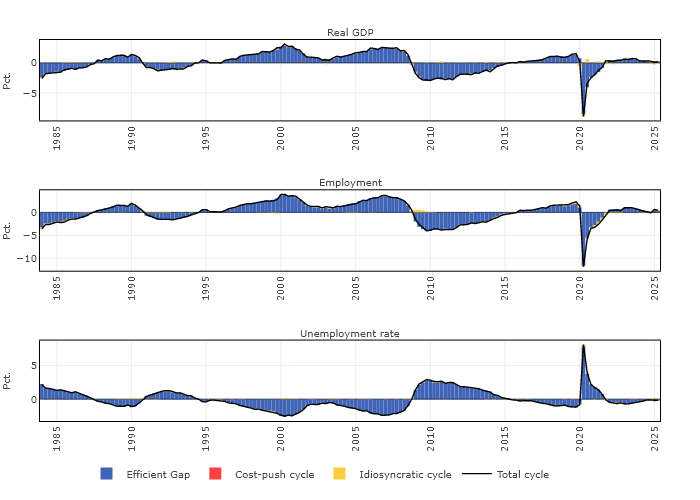

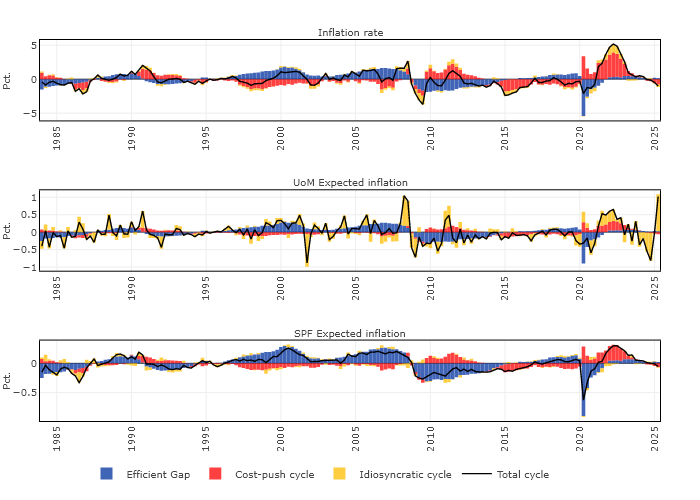

In [11]:
figures = Array{Any}(undef, 8);

for i=1:3
    trace1 = pltjs.bar(;x=date[1:end-max_h], y=Ψeᵐ[1:end-max_h, i], name="Efficient Gap", marker_color=c1, showlegend=i==1);
    trace2 = pltjs.bar(x=date[1:end-max_h], y=Ψπᵐ[1:end-max_h, i], name="Cost-push cycle", marker_color=c2, showlegend=i==1);
    trace3 = pltjs.bar(x=date[1:end-max_h], y=iCᵐ[1:end-max_h, i], name="Idiosyncratic cycle", marker_color=c3, showlegend=i==1);
    trace4 = pltjs.scatter(x=date[1:end-max_h], y=Ψeᵐ[1:end-max_h, i]+Ψπᵐ[1:end-max_h, i]+iCᵐ[1:end-max_h, i], name="Total cycle", mode="lines", line=attr(width=1.4, color="black"), showlegend=i==1)
    
    databar = [trace1, trace2, trace3, trace4];    
    layout  = pltjs.Layout(;title=titles[i], titlefont_size=12,
                           xaxis=attr(tickfont_size=10, showgrid=true, linecolor="black", mirror=true, titlefont=attr(size=10), nticks=20, tickangle=-90),
                           yaxis=attr(tickfont_size=10, showgrid=true, linecolor="black", mirror=true, titlefont=attr(size=10), title=scales[i]),
                           barmode="relative", 
                           bargap=0,
                           bargroupgap=0);

    figures[i] = pltjs.plot(databar, layout);
end

fig = [figures[1]; figures[2]; figures[3]]


# Bars
fig.plot.layout["barmode"] = "relative";
fig.plot.layout["bargap"]  = 0.02;

# Size
fig.plot.layout["width"]  = 800;
fig.plot.layout["height"] = 600;

# Margins
fig.plot.layout["margin"][:b]  = 40;
fig.plot.layout["margin"][:t]  = 40;
fig.plot.layout["margin"][:r]  = 40;
fig.plot.layout["margin"][:l]  = 40;

# Title size
for i=1:3
    fig.plot.layout["annotations"][i][:font][:size] = 10;
end

# Legend
fig.plot.layout["legend"] = attr(orientation="h", y=-0.1, x=0.075, font=attr(size=10))
PlotlyKaleido.savefig(fig, "$(results_folder)/historical_decomposition_observables_1_3.png")
display("image/png", read("$(results_folder)/historical_decomposition_observables_1_3.png"))



figures = Array{Any}(undef, 8);

for i=4:6
    trace1 = pltjs.bar(;x=date[1:end-max_h], y=Ψeᵐ[1:end-max_h, i], name="Efficient Gap", marker_color=c1, showlegend=i==4);
    trace2 = pltjs.bar(x=date[1:end-max_h], y=Ψπᵐ[1:end-max_h, i], name="Cost-push cycle", marker_color=c2, showlegend=i==4);
    trace3 = pltjs.bar(x=date[1:end-max_h], y=iCᵐ[1:end-max_h, i], name="Idiosyncratic cycle", marker_color=c3, showlegend=i==4);
    trace4 = pltjs.scatter(x=date[1:end-max_h], y=Ψeᵐ[1:end-max_h, i]+Ψπᵐ[1:end-max_h, i]+iCᵐ[1:end-max_h, i], name="Total cycle", mode="lines", line=attr(width=1.4, color="black"), showlegend=i==4);

    databar = [trace1, trace2, trace3, trace4];
    layout  = pltjs.Layout(;title=titles[i], titlefont_size=12,
                           xaxis=attr(tickfont_size=10, showgrid=true, linecolor="black", mirror=true, titlefont=attr(size=10), nticks=20, tickangle=-90),
                           yaxis=attr(tickfont_size=10, showgrid=true, linecolor="black", mirror=true, titlefont=attr(size=10), title=scales[i]),
                           barmode="relative", 
                           bargap=0,
                           bargroupgap=0);

    figures[i] = pltjs.plot(databar, layout);
end

fig = [figures[4]; figures[5]; figures[6]]


# Bars
fig.plot.layout["barmode"] = "relative";
fig.plot.layout["bargap"]  = 0.02;

# Size
fig.plot.layout["width"]  = 800;
fig.plot.layout["height"] = 600;

# Margins
fig.plot.layout["margin"][:b]  = 40;
fig.plot.layout["margin"][:t]  = 40;
fig.plot.layout["margin"][:r]  = 40;
fig.plot.layout["margin"][:l]  = 40;

# Title size
for i=1:3
    fig.plot.layout["annotations"][i][:font][:size] = 10;
end

# Legend
fig.plot.layout["legend"] = attr(orientation="h", y=-0.1, x=0.075, font=attr(size=10))
PlotlyKaleido.savefig(fig, "$(results_folder)/historical_decomposition_observables_4_5.png")
display("image/png", read("$(results_folder)/historical_decomposition_observables_4_5.png"))


#### Posteriors: key parameters

In [12]:
# ----- Frequency -----

# - Chart
figures    = Array{Any}(undef, 2)
titles_sub = ["Frequency, g^e cycle",
              "Frequency, g^π cycle"];

for i in 1:2
    idx = par_size.R + par_size.d + par_size.Z + par_size.Z_plus +
          par_size.Q + par_size.Q_cov + par_size.H + par_size.c +
          par_size.T + i

    row = chain_θ_bound[idx, :]

    println("Mean frequency $i: ",  mean(row))
    println("Median frequency $i: ", median(row))

    k             = kde(row)
    kde_x         = k.x
    x_prior       = collect(0:0.01:pi)
    kde_prior     = pdf(Uniform(0, pi), x_prior)
    kde_posterior = k.density

    trace1 = pltjs.scatter(x=x_prior, y=kde_prior,
                           line=attr(width=1.4, color=c2),
                           name="Prior", showlegend=false)
    trace2 = pltjs.scatter(x=kde_x, y=kde_posterior,
                           line=attr(width=1.4, color=c1),
                           name="Posterior", showlegend=false)

    layout = pltjs.Layout(; title=titles_sub[i], titlefont=attr(size=12),
                           xaxis=attr(tickfont_size=10, showgrid=true,
                                      linecolor="black", mirror=true,
                                      zeroline=false, titlefont=attr(size=10),
                                      range=[0, pi]),
                           yaxis=attr(tickfont_size=10, showgrid=true,
                                      linecolor="black", mirror=true,
                                      zeroline=false, titlefont=attr(size=10),
                                      title="Density"))

    figures[i] = pltjs.plot([trace1; trace2], layout)
end


Mean frequency 1: 0.10502876404429777
Median frequency 1: 0.10466620128919762
Mean frequency 2: 0.1476961439748239
Median frequency 2: 0.14520031382859228


In [13]:
# ----- Persistence -----

# - Chart
figures2    = Array{Any}(undef, 2)
titles_sub = ["Persistence, g^e cycle",
              "Persistence, g^π cycle"];

for i=1:2

    idx = par_size.R+par_size.d+par_size.Z+par_size.Z_plus+par_size.Q+par_size.Q_cov+par_size.H+par_size.c+par_size.T+par_size.λ+i
    
    row = chain_θ_bound[idx, :]

    println("Mean persistence $i: ",  mean(row))
    println("Median persistence $i: ", median(row))


    k             = kde(row)
    kde_x         = k.x
    x_prior       = collect(0:0.01:1)
    kde_prior     = pdf(Uniform(0, 1), x_prior)
    kde_posterior = k.density

    trace1 = pltjs.scatter(x=x_prior, y=kde_prior,
                           line=attr(width=1.4, color=c2),
                           name="Prior", showlegend=false)
    trace2 = pltjs.scatter(x=kde_x, y=kde_posterior,
                           line=attr(width=1.4, color=c1),
                           name="Posterior", showlegend=false)

    layout = pltjs.Layout(; title=titles_sub[i], titlefont=attr(size=12),
                           xaxis=attr(tickfont_size=10, showgrid=true,
                                      linecolor="black", mirror=true,
                                      zeroline=false, titlefont=attr(size=10),
                                      range=[0, 1]),
                           yaxis=attr(tickfont_size=10, showgrid=true,
                                      linecolor="black", mirror=true,
                                      zeroline=false, titlefont=attr(size=10),
                                      title="Density"))

    figures2[i] = pltjs.plot([trace1; trace2], layout);
end


Mean persistence 1: 0.8649676280350036
Median persistence 1: 0.8698814308429239
Mean persistence 2: 0.8951952445651147
Median persistence 2: 0.9056343725452022


In [14]:
# ----- Variance -----

# - Chart
figures_var    = Array{Any}(undef, 2)
titles_sub = ["Variance, g^e cycle", 
              "Variance, g^π cycle"];

for i=1:2
    idx = par_size.R+par_size.d+par_size.Z + par_size.Z_plus + i

    row = chain_θ_bound[idx, :]

    println("Mean variance $i: ",  mean(row))
    println("Median variance $i: ", median(row))


    k             = kde(row)
    kde_x         = k.x
    x_prior       = collect(0:0.01:2)
    kde_prior     = pdf(Uniform(0, 2), x_prior)
    kde_posterior = k.density

    trace1 = pltjs.scatter(x=x_prior, y=kde_prior,
                           line=attr(width=1.4, color=c2),
                           name="Prior", showlegend=false)
    trace2 = pltjs.scatter(x=kde_x, y=kde_posterior,
                           line=attr(width=1.4, color=c1),
                           name="Posterior", showlegend=false)

    layout = pltjs.Layout(; title=titles_sub[i], titlefont=attr(size=12),
                           xaxis=attr(tickfont_size=10, showgrid=true,
                                      linecolor="black", mirror=true,
                                      zeroline=false, titlefont=attr(size=10),
                                      range=[0, 2]),
                           yaxis=attr(tickfont_size=10, showgrid=true,
                                      linecolor="black", mirror=true,
                                      zeroline=false, titlefont=attr(size=10),
                                      title="Density"))


    figures_var[i] = pltjs.plot([trace1; trace2], layout);
end


Mean variance 1: 0.7323405383443466
Median variance 1: 0.7174058530300017
Mean variance 2: 0.3111023575412565
Median variance 2: 0.3076282315830099


In [15]:
# ----- CoVariance -----

figures_covar = Array{Any}(undef, 1)

# Pick which parameter we're plotting (Q_cov correlation or H contemporaneous effect)
if par_size.Q_cov > 0
    title    = "Correlation, g^e and g^π"
    idx_corr = par_size.R + par_size.d + par_size.Z + par_size.Z_plus + par_size.Q + 1
    row = chain_θ_bound[idx_corr, :]
    println("Correlation (g^e, g^π): ", mean(row))
    k = kde(row)

elseif par_size.H > 0
    title  = "Contemporaneous Effect of g^π on g^e"
    idx_H  = par_size.R + par_size.d + par_size.Z + par_size.Z_plus + par_size.Q + par_size.Q_cov + 1
    row = chain_θ_bound[idx_H, :]
    println("Contemporaneous effect: ", mean(row))
    k = kde(row)

else
    println("No parameter estimated.")
    title = ""
    k     = kde(zeros(1, 2))
end

kde_x         = k.x
x_prior       = collect(-1.0:0.01:1.0)
kde_prior     = pdf.(Normal(0, 1000), x_prior)
kde_posterior = k.density

trace1 = pltjs.scatter(
    x=x_prior, y=kde_prior,
    line=attr(width=1.4, color=c2),
    name="Prior", showlegend=false
)

trace2 = pltjs.scatter(
    x=kde_x, y=kde_posterior,
    line=attr(width=1.4, color=c1),
    name="Posterior", showlegend=false
)

layout = pltjs.Layout(;
    title     = title,
    titlefont = attr(size=12),
    xaxis     = attr(
        tickfont_size=10, showgrid=true, linecolor="black",
        mirror=true, zeroline=false, titlefont=attr(size=10),
        range=[-1.0, 1.0]
    ),
    yaxis     = attr(
        tickfont_size=10, showgrid=true, linecolor="black",
        mirror=true, zeroline=false, titlefont=attr(size=10),
        title="Density"
    )
)

figures_covar[1] = pltjs.plot([trace1; trace2], layout)

figures_covar[1].plot.layout["width"]  = 700
figures_covar[1].plot.layout["height"] = 300


Correlation (g^e, g^π): -0.6221330699602243


300

In [16]:
# ----- Phillips curve slope κ -----

# - Chart
figures_phillip = Array{Any}(undef, 1)
titles_sub = ["Slope of Phillips curve κ"];


for i=1:1
    idx = par_size.R+par_size.d+par_size.Z + 1

    row = chain_θ_bound[idx, :]

    println("Mean κ $i: ",  mean(row))
    println("Median κ $i: ", median(row))


    k             = kde(row)
    kde_x         = k.x
    x_prior       = collect(0:0.01:1)
    kde_prior     = pdf(Uniform(0, 1), x_prior)
    kde_posterior = k.density

    trace1 = pltjs.scatter(x=x_prior, y=kde_prior,
                           line=attr(width=1.4, color=c2),
                           name="Prior", showlegend=false)
    trace2 = pltjs.scatter(x=kde_x, y=kde_posterior,
                           line=attr(width=1.4, color=c1),
                           name="Posterior", showlegend=false)

    layout = pltjs.Layout(; title=titles_sub[i], titlefont=attr(size=12),
                           xaxis=attr(tickfont_size=10, showgrid=true,
                                      linecolor="black", mirror=true,
                                      zeroline=false, titlefont=attr(size=10),
                                      range=[0, 1]),
                           yaxis=attr(tickfont_size=10, showgrid=true,
                                      linecolor="black", mirror=true,
                                      zeroline=false, titlefont=attr(size=10),
                                      title="Density"))


    figures_phillip[i] = pltjs.plot([trace1; trace2], layout)

end


Mean κ 1: 0.7546116069612683
Median κ 1: 0.7571895926761644


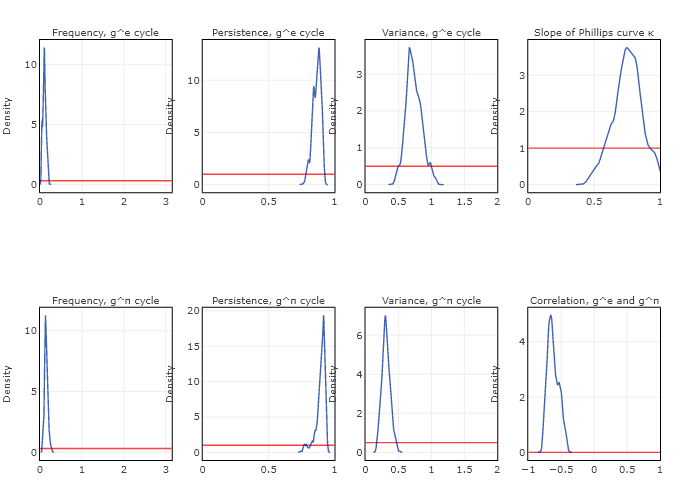

In [17]:
# Combine posterior parameter plots
empty = pltjs.plot();
fig = [figures[1] figures2[1] figures_var[1] figures_phillip[1]  ; figures[2] figures2[2]  figures_var[2] figures_covar[1]];

# Size
fig.plot.layout["width"]  = 1000;
fig.plot.layout["height"] = 600;

# Bars
fig.plot.layout["bargap"]      = 0;
fig.plot.layout["bargroupgap"] = 0;

# Margins
fig.plot.layout["margin"][:b]  = 40;
fig.plot.layout["margin"][:t]  = 40;
fig.plot.layout["margin"][:r]  = 40;
fig.plot.layout["margin"][:l]  = 40;

# Title size
for i=1:8
    fig.plot.layout["annotations"][i][:font][:size] = 10;
end

# Legend
fig.plot.layout["legend"] = attr(orientation="h", y=-0.1, x=0.42, font=attr(size=10))

PlotlyKaleido.savefig(fig, "$(results_folder)/posterior_key_parameters_combined.png")
display("image/png", read("$(results_folder)/posterior_key_parameters_combined.png"))


#### Trends

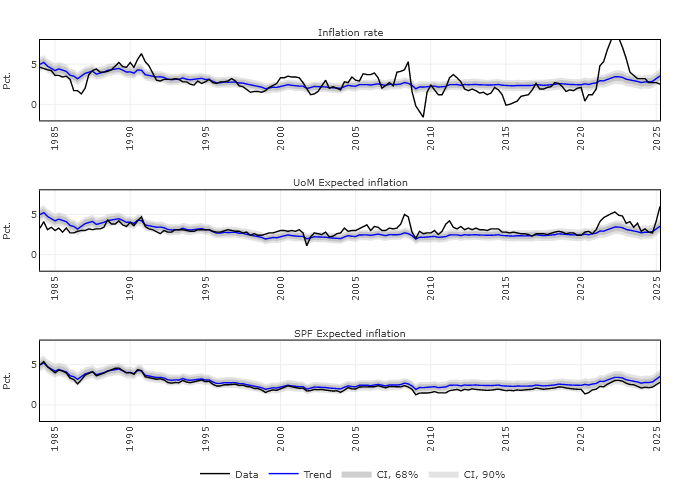

In [18]:
figures=Array{Any}(undef, 4)


for i=4:6
    
     trace0 = pltjs.scatter(;x=date[1:end-max_h], y=data[1:end-max_h, i], name="Data", mode="lines", line=attr(width=1.4, color="black"), showlegend=i==5);
     trace1 = pltjs.scatter(;x=date[1:end-max_h], y=Tᵐ[1:end-max_h, i], name="Trend", mode="lines", line=attr(color="rgba(0,0,0,0)"), showlegend=false);
     trace2 = pltjs.scatter(;x=date[1:end-max_h], y=T95[1:end-max_h, i], name="CI, 90%", mode="lines", fill="tonexty", fillcolor="rgba(185, 185, 185, .40)", line_color="transparent", showlegend=i==5);
     trace3 = pltjs.scatter(;x=date[1:end-max_h], y=T05[1:end-max_h, i], name="CI, 90%", mode="lines", fill="tonexty", fillcolor="rgba(185, 185, 185, .40)", line_color="transparent", showlegend=false);
     trace4 = pltjs.scatter(;x=date[1:end-max_h], y=T84[1:end-max_h, i], name="CI, 68%", mode="lines", fill="tonexty", fillcolor="rgba(185, 185, 185, .70)", line_color="transparent", showlegend=i==5);
     trace5 = pltjs.scatter(;x=date[1:end-max_h], y=T16[1:end-max_h, i], name="CI, 68%", mode="lines", fill="tonexty", fillcolor="rgba(185, 185, 185, .70)", line_color="transparent", showlegend=false);
     trace6 = pltjs.scatter(;x=date[1:end-max_h], y=Tᵐ[1:end-max_h, i], name="Trend", mode="lines", line=attr(width=1.4, color="rgba(0,0,255,1)"), showlegend=i==5);

     layout  = pltjs.Layout(;title=titles[i], titlefont=attr(size=12),
                            xaxis=attr(tickfont_size=10, showgrid=true, linecolor="black", mirror=true, nticks=20, tickangle=-90, zeroline=false),
                            yaxis=attr(tickfont_size=10, showgrid=true, linecolor="black", mirror=true, zeroline=false, titlefont=attr(size=10), title=scales[i], range=[-2,8]));

     figures[i-3] = pltjs.plot([trace1; trace2; 
                              trace1; trace3; 
                              trace1; trace4;
                              trace1; trace5; 
                              trace6; trace0], layout);
end

fig = [figures[1]; figures[2]; figures[3]];

fig.plot.layout["width"]  = 600;
fig.plot.layout["height"] = 800;

# Margins
fig.plot.layout["margin"][:b]  = 40;
fig.plot.layout["margin"][:t]  = 40;
fig.plot.layout["margin"][:r]  = 40;
fig.plot.layout["margin"][:l]  = 40;

# Title size
for i=1:3
    fig.plot.layout["annotations"][i][:font][:size] = 10;
end

# Legend
fig.plot.layout["legend"] = attr(orientation="h", y=-0.10, x=0.25, font=attr(size=10))

PlotlyKaleido.savefig(fig, "$(results_folder)/trends_inflation_observables.png")
display("image/png", read("$(results_folder)/trends_inflation_observables.png"))

#### Gaps


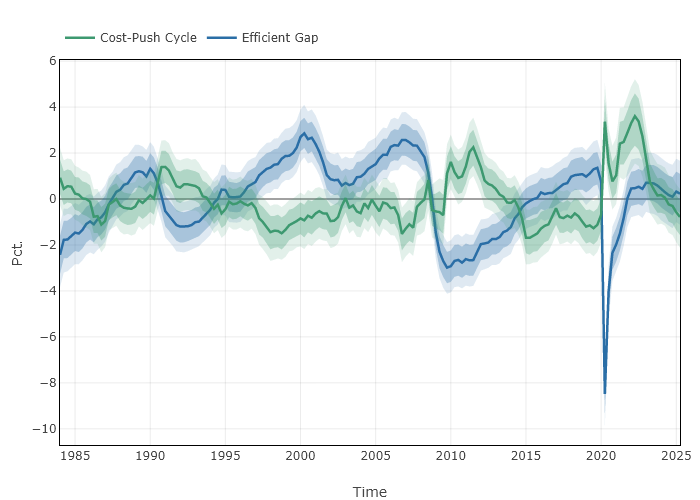

UndefVarError: UndefVarError: `EP05_HZ` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [19]:

eff_color = "#2A6EA6"   # eff
flex_color    = "#B33A3A"   # flex
u_color      = "#3D9970"   # cost-push
band68_eff   = "rgba(42, 110, 166, 0.30)" # inner band (blue)
band90_eff  = "rgba(42, 110, 166, 0.15)" # outer band (blue)
band68_flex   = "rgba(179, 58, 58, 0.30)" # inner band (red)
band90_flex  = "rgba(179, 58, 58, 0.15)" # outer band (red)
band68_u     = "rgba(61, 153, 112, 0.30)" # inner band (green)
band90_u    = "rgba(61, 153, 112, 0.15)" # outer band (green)

HZ_color = "#DB4437"  # HZ energy price cycle
band_68_HZ = "rgba(219, 68, 55, 0.30)" # inner band (red)
band_90_HZ = "rgba(219, 68, 55, 0.15)" # outer band (red)

# states
# eff Ψeᵐ
# cost-push Ψπᵐ
# flex Ψfᵐ

# --- Reusable layout (set limits if you want) ---
y_lims = (-10, 10)  # <- adjust or comment out if not desired

base_layout = Layout(
    template="plotly_white", hovermode="x unified",
    width=900, height=420, margin=attr(l=60, r=20, t=60, b=55),
    xaxis=attr(
        title="Time", showgrid=true, gridcolor="rgba(0,0,0,0.08)",
        zeroline=false, showline=true, linecolor="black", linewidth=1, mirror=true
    ),
    yaxis=attr(
        title="Pct.", showgrid=true, gridcolor="rgba(0,0,0,0.08)",
        zeroline=true, showline=true, linecolor="black", linewidth=1, mirror=true,
        # range=[y_lims...]    # comment this line out to auto-scale
    ),
    legend=attr(orientation="h", x=0.0, y=1.02, yanchor="bottom", bgcolor="rgba(0,0,0,0)")
)


# ============= gaps
plt_cycle = Plot([
        # Efficient gap
        # 90% band: lower first (invisible), then upper filled to previous
        scatter(x=date, y=Ψe05[1:end-max_h, 1], mode="lines",
                line=attr(color="rgba(0,0,0,0)"), hoverinfo="skip", showlegend=false),
        scatter(x=date, y=Ψe95[1:end-max_h, 1], mode="lines", showlegend=false,
                fill="tonexty", fillcolor=band90_eff, line=attr(color="rgba(0,0,0,0)")),

        # 68% band: lower first (invisible), then upper filled to previous
        scatter(x=date, y=Ψe16[1:end-max_h, 1], mode="lines",
                line=attr(color="rgba(0,0,0,0)"), hoverinfo="skip", showlegend=false),
        scatter(x=date, y=Ψe84[1:end-max_h, 1], mode="lines", showlegend=false,
                fill="tonexty", fillcolor=band68_eff, line=attr(color="rgba(0,0,0,0)")),
        # Median line
        scatter(x=date, y=Ψeᵐ[1:end-max_h, 1], mode="lines", name="Efficient Gap", legendrank=1,
                line=attr(color=eff_color, width=2.5)),

        # cost push cycle
        # 90% band: lower first (invisible), then upper filled to previous
        scatter(x=date, y=Ψπ05[1:end-max_h, 4], mode="lines",
                line=attr(color="rgba(0,0,0,0)"), hoverinfo="skip", showlegend=false),
        scatter(x=date, y=Ψπ95[1:end-max_h, 4], mode="lines", showlegend=false,
                fill="tonexty", fillcolor=band90_u, line=attr(color="rgba(0,0,0,0)")),
        # 68% band: lower first (invisible), then upper filled to previous
        scatter(x=date, y=Ψπ16[1:end-max_h, 4], mode="lines",
                line=attr(color="rgba(0,0,0,0)"), hoverinfo="skip", showlegend=false),
        scatter(x=date, y=Ψπ84[1:end-max_h, 4], mode="lines", showlegend=false,
                fill="tonexty", fillcolor=band68_u, line=attr(color="rgba(0,0,0,0)")),
        # Median line
        scatter(x=date, y=Ψπᵐ[1:end-max_h, 4], mode="lines", name="Cost-Push Cycle", legendrank=2,
                line=attr(color=u_color, width=2.5)),

        # # Flex price gap
        # # 90% band: lower first (invisible), then upper filled to previous
        # scatter(x=date, y=Ψf05[1:end-max_h, 1], mode="lines",
        #         line=attr(color="rgba(0,0,0,0)"), hoverinfo="skip", showlegend=false),
        # scatter(x=date, y=Ψf95[1:end-max_h, 1], mode="lines", showlegend=false,
        #         fill="tonexty", fillcolor=band90_flex, line=attr(color="rgba(0,0,0,0)")),  
        # # 68% band: lower first (invisible), then upper filled to previous
        # scatter(x=date, y=Ψf16[1:end-max_h, 1], mode="lines",
        #         line=attr(color="rgba(0,0,0,0)"), hoverinfo="skip", showlegend=false),
        # scatter(x=date, y=Ψf84[1:end-max_h, 1], mode="lines", showlegend=false,
        #         fill="tonexty", fillcolor=band68_flex, line=attr(color="rgba(0,0,0,0)")),
        # # Median line
        # scatter(x=date, y=Ψfᵐ[1:end-max_h, 1], mode="lines", name="Flex Price Gap", legendrank=3,
        #         line=attr(color=flex_color, width=2.5)),

],
base_layout)
PlotlyKaleido.savefig(plt_cycle, "$(results_folder)/gaps_efficient_cost_push_and_flex.png")
display("image/png", read("$(results_folder)/gaps_efficient_cost_push_and_flex.png"))


### cost-push & energy price cycle
plt_cp_ep = Plot([
        # cost push cycle
        # 90% band: lower first (invisible), then upper filled to previous
        scatter(x=date, y=Ψπ05[1:end-max_h, 4], mode="lines",
                line=attr(color="rgba(0,0,0,0)"), hoverinfo="skip", showlegend=false),
        scatter(x=date, y=Ψπ95[1:end-max_h, 4], mode="lines", showlegend=false,
                fill="tonexty", fillcolor=band90_u, line=attr(color="rgba(0,0,0,0)")),
        # 68% band: lower first (invisible), then upper filled to previous
        scatter(x=date, y=Ψπ16[1:end-max_h, 4], mode="lines",
                line=attr(color="rgba(0,0,0,0)"), hoverinfo="skip", showlegend=false),
        scatter(x=date, y=Ψπ84[1:end-max_h, 4], mode="lines", showlegend=false,
                fill="tonexty", fillcolor=band68_u, line=attr(color="rgba(0,0,0,0)")),
        # Median line
        scatter(x=date, y=Ψπᵐ[1:end-max_h, 4], mode="lines", name="Cost-Push Cycle", legendrank=1,
                line=attr(color=u_color, width=2.5)),

        # HZ Energy Price Cycle
        # 90% band: lower first (invisible), then upper filled to previous
        scatter(x=date, y=EP05_HZ[1:end-max_h, 5], mode="lines",
                line=attr(color="rgba(0,0,0,0)"), hoverinfo="skip", showlegend=false),
        scatter(x=date, y=EP95_HZ[1:end-max_h, 5], mode="lines", showlegend=false,
                fill="tonexty", fillcolor=band_90_HZ, line=attr(color="rgba(0,0,0,0)")),
        # 68% band: lower first (invisible), then upper filled to previous
        scatter(x=date, y=EP16_HZ[1:end-max_h, 5], mode="lines",
                line=attr(color="rgba(0,0,0,0)"), hoverinfo="skip", showlegend=false),
        scatter(x=date, y=EP84_HZ[1:end-max_h, 5], mode="lines", showlegend=false,
                fill="tonexty", fillcolor=band_68_HZ, line=attr(color="rgba(0,0,0,0)")),
        # Median line
        scatter(x=date, y=EPᵐ_HZ[1:end-max_h, 5], mode="lines", name="Energy Price Cycle", legendrank=2,
                line=attr(color=HZ_color, width=2.5)),
],
base_layout)
PlotlyKaleido.savefig(plt_cp_ep, "$(results_folder)/cost_push_energy_price_comparison.png")
display("image/png", read("$(results_folder)/cost_push_energy_price_comparison.png"))


# correlation between cost-push and energy price cycle
correlation_cp_ep = cor(EPᵐ_HZ[1:end-max_h, 5], Ψπᵐ[1:end-max_h, 4])
println("Correlation between cost-push and energy price cycle: ", correlation_cp_ep)

In [20]:
# load model 1 and model 2 results for comparison
res_1           = load("$(pwd())/res_kuttner_AR2_4_obs_iis.jld2");
nDraws_1        = res_1["nDraws"];
burnin_1        = res_1["burnin"];
distr_α_1       = res_1["distr_α"];
σʸ            = res_1["σʸ"]';

Ψe1          = zeros(size(distr_α_1, 2), size(distr_α_1, 3));
Ψe1[:, :] = distr_α_1[1, :, :].*σʸ[1];



res_2           = load("$(pwd())/res_okun_kuttner_AR2_6_obs_iis.jld2");
nDraws_2        = res_2["nDraws"];
burnin_2       = res_2["burnin"];
distr_α_2      = res_2["distr_α"];
σʸ            = res_2["σʸ"]';

Ψe2          = zeros(size(distr_α_2, 2), size(distr_α_2, 3));
Ψe2[:, :] = distr_α_2[1, :, :].*σʸ[1];

Ψe1ᵐ = zeros(size(Ψe1, 1)-max_h);
Ψe2ᵐ = zeros(size(Ψe2, 1)-max_h);
Ψe195 = zeros(size(Ψe1, 1)-max_h);
Ψe105 = zeros(size(Ψe1, 1)-max_h);
Ψe184 = zeros(size(Ψe1, 1)-max_h);
Ψe116 = zeros(size(Ψe1, 1)-max_h);
Ψe295 = zeros(size(Ψe2, 1)-max_h);
Ψe205 = zeros(size(Ψe2, 1)-max_h);
Ψe284 = zeros(size(Ψe2, 1)-max_h);
Ψe216 = zeros(size(Ψe2, 1)-max_h);


# fill quantiles
for j=1:size(Ψe1, 1)-max_h
    Ψe195[j] = quantile(Ψe1[j, :], 0.95);
    Ψe105[j] = quantile(Ψe1[j, :], 0.05);
    Ψe184[j] = quantile(Ψe1[j, :], 0.84); 
    Ψe116[j] = quantile(Ψe1[j, :], 0.16);
    Ψe1ᵐ[j]  = quantile(Ψe1[j, :], 0.50);

    Ψe295[j] = quantile(Ψe2[j, :], 0.95);
    Ψe205[j] = quantile(Ψe2[j, :], 0.05);
    Ψe284[j] = quantile(Ψe2[j, :], 0.84); 
    Ψe216[j] = quantile(Ψe2[j, :], 0.16);
    Ψe2ᵐ[j]  = quantile(Ψe2[j, :], 0.50);
end


# make comparison plot
# black
model1_color = "#000000"  # black for Model 1
model2_color = "#000000"  


# ============= gaps
plt_cycle = Plot([

              # Flex price gap
        # 90% band: lower first (invisible), then upper filled to previous
        scatter(x=date, y=Ψf05[1:end-max_h, 1], mode="lines",
                line=attr(color="rgba(0,0,0,0)"), hoverinfo="skip", showlegend=false),
        scatter(x=date, y=Ψf95[1:end-max_h, 1], mode="lines", showlegend=false,
                fill="tonexty", fillcolor=band90_flex, line=attr(color="rgba(0,0,0,0)")),  
        # 68% band: lower first (invisible), then upper filled to previous
        scatter(x=date, y=Ψf16[1:end-max_h, 1], mode="lines",
                line=attr(color="rgba(0,0,0,0)"), hoverinfo="skip", showlegend=false),
        scatter(x=date, y=Ψf84[1:end-max_h, 1], mode="lines", showlegend=false,
                fill="tonexty", fillcolor=band68_flex, line=attr(color="rgba(0,0,0,0)")),
        # Median line
        scatter(x=date, y=Ψfᵐ[1:end-max_h, 1], mode="lines", name="Flex Price Gap", legendrank=3,
                line=attr(color=flex_color, width=2.5)),
                
        # Efficient gap
        # 90% band: lower first (invisible), then upper filled to previous
        scatter(x=date, y=Ψe05[1:end-max_h, 1], mode="lines",
                line=attr(color="rgba(0,0,0,0)"), hoverinfo="skip", showlegend=false),
        scatter(x=date, y=Ψe95[1:end-max_h, 1], mode="lines", showlegend=false,
                fill="tonexty", fillcolor=band90_eff, line=attr(color="rgba(0,0,0,0)")),

        # 68% band: lower first (invisible), then upper filled to previous
        scatter(x=date, y=Ψe16[1:end-max_h, 1], mode="lines",
                line=attr(color="rgba(0,0,0,0)"), hoverinfo="skip", showlegend=false),
        scatter(x=date, y=Ψe84[1:end-max_h, 1], mode="lines", showlegend=false,
                fill="tonexty", fillcolor=band68_eff, line=attr(color="rgba(0,0,0,0)")),
        # Median line
        scatter(x=date, y=Ψeᵐ[1:end-max_h, 1], mode="lines", name="Efficient Gap", legendrank=1,
                line=attr(color=eff_color, width=2.5)),

        # # cost push cycle
        # # 90% band: lower first (invisible), then upper filled to previous
        # scatter(x=date, y=Ψπ05[1:end-max_h, 4], mode="lines",
        #         line=attr(color="rgba(0,0,0,0)"), hoverinfo="skip", showlegend=false),
        # scatter(x=date, y=Ψπ95[1:end-max_h, 4], mode="lines", showlegend=false,
        #         fill="tonexty", fillcolor=band90_u, line=attr(color="rgba(0,0,0,0)")),
        # # 68% band: lower first (invisible), then upper filled to previous
        # scatter(x=date, y=Ψπ16[1:end-max_h, 4], mode="lines",
        #         line=attr(color="rgba(0,0,0,0)"), hoverinfo="skip", showlegend=false),
        # scatter(x=date, y=Ψπ84[1:end-max_h, 4], mode="lines", showlegend=false,
        #         fill="tonexty", fillcolor=band68_u, line=attr(color="rgba(0,0,0,0)")),
        # # Median line
        # scatter(x=date, y=Ψπᵐ[1:end-max_h, 4], mode="lines", name="Cost-Push Cycle", legendrank=2,
        #         line=attr(color=u_color, width=2.5)),

  
                # Model 2 efficient gap
        scatter(x=date, y=Ψe2ᵐ, mode="lines", name="Model 2 Gap", legendrank=4,
                line=attr(color=model2_color, width=2.5, dash="dash")),

        # Model 1 efficient gap
        scatter(x=date, y=Ψe1ᵐ, mode="lines", name="Model 1 Gap", legendrank=5,
                line=attr(color=model1_color, width=2.5, dash="dot")),



],
base_layout)
PlotlyKaleido.savefig(plt_cycle, "$(results_folder)/gaps_comparison_with_Kuttner_Okun.png")
display("image/png",read("$(results_folder)/gaps_comparison_with_Kuttner_Okun.png"))


# compute correlation between model 1 median and flex gap median
corr = cor(Ψe1ᵐ, Ψfᵐ[1:end-max_h, 1])
display("Correlation between Kuttner gap and Flex price gap: $(corr)")

corr2 = cor(Ψe2ᵐ, Ψfᵐ[1:end-max_h, 1])
display("Correlation between Okun-Kuttner  gap and Flex price gap: $(corr2)")

corr = cor(Ψe1ᵐ, Ψeᵐ[1:end-max_h, 1])
display("Correlation between Kuttner  gap and current model efficient gap: $(corr)")

corr2 = cor(Ψe2ᵐ, Ψeᵐ[1:end-max_h, 1])
display("Correlation between Okun-Kuttner  gap and current model efficient gap: $(corr2)")


# relative volatility of flex gap to efficient gap
rel_vol1 = std(Ψe1ᵐ) /  std(Ψfᵐ[1:end-max_h, 1])
display("Relative volatility of kuttner to flex gap: $(rel_vol1)")

rel_vol2 = std(Ψe2ᵐ) / std(Ψfᵐ[1:end-max_h, 1])
display("Relative volatility of okun kuttner to flex gap: $(rel_vol2)")

rel_vol1 = std(Ψe1ᵐ)/ std(Ψeᵐ[1:end-max_h, 1]) 
display("Relative volatility of kuttner gap to efficient gap: $(rel_vol1)")

rel_vol2 = std(Ψe2ᵐ) / std(Ψeᵐ[1:end-max_h, 1])
display("Relative volatility of okun-kuttner gap to efficient  gap: $(rel_vol2)")


ArgumentError: ArgumentError: No file exists at given path: c:\Users\wrc938\OneDrive - University of Copenhagen\PhD\1. Projects\1. Estimating output gaps\code empirical-main/res_kuttner_AR2_4_obs_iis.jld2

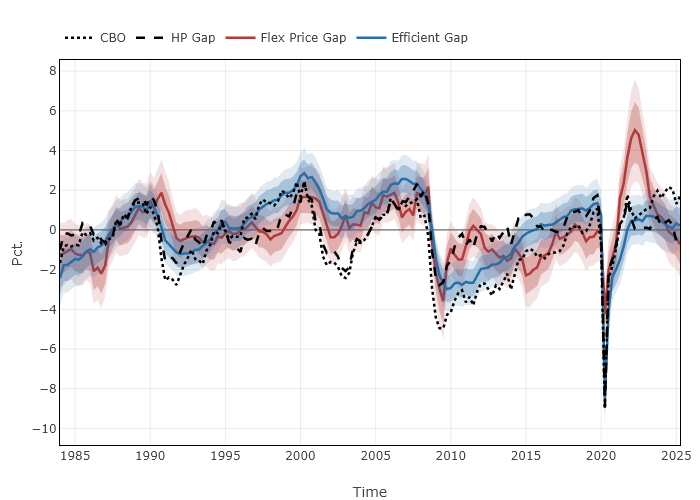

"Correlation between Efficient gap and HP gap: 0.7118387329289421"

"Correlation between Flex price gap and HP gap: 0.4956724365401341"

"Relative volatility of HP gap to Efficient gap: 0.7569591178188073"

"Relative volatility of HP gap to Flex price gap: 0.8586812687384924"

"Correlation between Efficient gap and CBO gap: 0.8021428007781388"

"Correlation between Flex price gap and CBO gap: 0.5919581624034043"

"Relative volatility of CBO gap to Efficient gap: 1.127486701763397"

"Relative volatility of CBO gap to Flex price gap: 1.2790013208979107"

In [21]:
include("code/filters.jl");
y = (data[1:end-max_h, 1]);
cbo_gap = CSV.read("./data/CBO_gap_2025.csv", DataFrame)[!, :GDPC1_GDPPOT];

hp_gap = HP_filter(y);

# ============= gaps
plt_cycle = Plot([

              # Flex price gap
        # 90% band: lower first (invisible), then upper filled to previous
        scatter(x=date, y=Ψf05[1:end-max_h, 1], mode="lines",
                line=attr(color="rgba(0,0,0,0)"), hoverinfo="skip", showlegend=false),
        scatter(x=date, y=Ψf95[1:end-max_h, 1], mode="lines", showlegend=false,
                fill="tonexty", fillcolor=band90_flex, line=attr(color="rgba(0,0,0,0)")),  
        # 68% band: lower first (invisible), then upper filled to previous
        scatter(x=date, y=Ψf16[1:end-max_h, 1], mode="lines",
                line=attr(color="rgba(0,0,0,0)"), hoverinfo="skip", showlegend=false),
        scatter(x=date, y=Ψf84[1:end-max_h, 1], mode="lines", showlegend=false,
                fill="tonexty", fillcolor=band68_flex, line=attr(color="rgba(0,0,0,0)")),
        # Median line
        scatter(x=date, y=Ψfᵐ[1:end-max_h, 1], mode="lines", name="Flex Price Gap", legendrank=3,
                line=attr(color=flex_color, width=2.5)),
                
        # Efficient gap
        # 90% band: lower first (invisible), then upper filled to previous
        scatter(x=date, y=Ψe05[1:end-max_h, 1], mode="lines",
                line=attr(color="rgba(0,0,0,0)"), hoverinfo="skip", showlegend=false),
        scatter(x=date, y=Ψe95[1:end-max_h, 1], mode="lines", showlegend=false,
                fill="tonexty", fillcolor=band90_eff, line=attr(color="rgba(0,0,0,0)")),

        # 68% band: lower first (invisible), then upper filled to previous
        scatter(x=date, y=Ψe16[1:end-max_h, 1], mode="lines",
                line=attr(color="rgba(0,0,0,0)"), hoverinfo="skip", showlegend=false),
        scatter(x=date, y=Ψe84[1:end-max_h, 1], mode="lines", showlegend=false,
                fill="tonexty", fillcolor=band68_eff, line=attr(color="rgba(0,0,0,0)")),
        # Median line
        scatter(x=date, y=Ψeᵐ[1:end-max_h, 1], mode="lines", name="Efficient Gap", legendrank=1,
                line=attr(color=eff_color, width=2.5)),
        
        # HP benchmark
        scatter(x=date[1:end-max_h], y=hp_gap, name="HP Gap", line=attr(width=2.5, color="#000000", dash="dash")),

        # CBO benchmark
        scatter(x=date[1:end-max_h], y=cbo_gap, name="CBO", line=attr(width=2.5, color="#000000", dash="dot"))

],
base_layout)
PlotlyKaleido.savefig(plt_cycle, "$(results_folder)/gaps_with_HP_CBO_benchmarks.png")
display("image/png",read("$(results_folder)/gaps_with_HP_CBO_benchmarks.png"))

# correlation
corr_hp = cor(Ψeᵐ[1:end-max_h, 1], hp_gap)
display("Correlation between Efficient gap and HP gap: $(corr_hp)")

corr_hp = cor(Ψfᵐ[1:end-max_h, 1], hp_gap)
display("Correlation between Flex price gap and HP gap: $(corr_hp)")

# relative volatility of flex gap to efficient gap
rel_vol_hp_eff = std(hp_gap) /  std(Ψeᵐ[1:end-max_h, 1])
display("Relative volatility of HP gap to Efficient gap: $(rel_vol_hp_eff)")

rel_vol_hp_flex = std(hp_gap) / std(Ψfᵐ[1:end-max_h, 1])
display("Relative volatility of HP gap to Flex price gap: $(rel_vol_hp_flex)")


# CORRELATIONS
corr_cbo = cor(Ψeᵐ[1:end-max_h, 1], cbo_gap)
display("Correlation between Efficient gap and CBO gap: $(corr_cbo)")

corr_cbo = cor(Ψfᵐ[1:end-max_h, 1], cbo_gap)
display("Correlation between Flex price gap and CBO gap: $(corr_cbo)")


# relative volatility of flex gap to efficient gap
rel_vol_cbo_eff = std(cbo_gap) /  std(Ψeᵐ[1:end-max_h, 1])
display("Relative volatility of CBO gap to Efficient gap: $(rel_vol_cbo_eff)")

rel_vol_cbo_flex = std(cbo_gap) / std(Ψfᵐ[1:end-max_h, 1])
display("Relative volatility of CBO gap to Flex price gap: $(rel_vol_cbo_flex)")

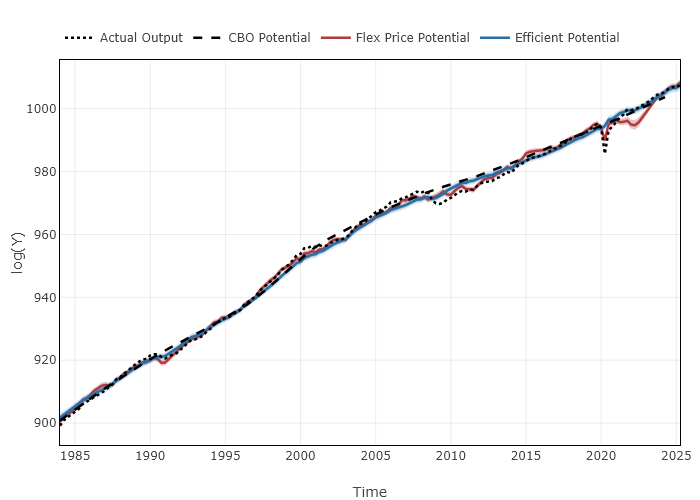

In [22]:
# potential output
cbo_gdp_potential = CSV.read("./data/CBO_potential_2025.csv", DataFrame)[!, :GDPPOT];
cbo_nairu = CSV.read("./data/CBO_NROU_2025.csv", DataFrame)[!, :NROU];
cbo_gdp_potential[ismissing.(cbo_gdp_potential)] .= NaN;
cbo_nairu[ismissing.(cbo_nairu)] .= NaN;
cbo_gdp_potential = log.(cbo_gdp_potential) .* 100;

plt_potential = Plot([
       
        # flex potential
        #  # 90% band: lower first (invisible), then upper filled to previous
        # scatter(x=date, y=yf05[1:end-max_h, 1], mode="lines",
        #         line=attr(color="rgba(0,0,0,0)"), hoverinfo="skip", showlegend=false),
        # scatter(x=date, y=yf95[1:end-max_h, 1], mode="lines", showlegend=false,
        #         fill="tonexty", fillcolor=band90_flex, line=attr(color="rgba(0,0,0,0)")),  
        # 68% band: lower first (invisible), then upper filled to previous
        scatter(x=date, y=yf16[1:end-max_h, 1], mode="lines",
                line=attr(color="rgba(0,0,0,0)"), hoverinfo="skip", showlegend=false),
        scatter(x=date, y=yf84[1:end-max_h, 1], mode="lines", showlegend=false,
                fill="tonexty", fillcolor=band68_flex, line=attr(color="rgba(0,0,0,0)")),
        # Median line
        scatter(x=date, y=yfᵐ[1:end-max_h, 1], mode="lines", name="Flex Price Potential", legendrank=2,
                line=attr(color=flex_color, width=2.5)),

        # Efficient potential
        # 90% band: lower first (invisible), then upper filled to previous
        scatter(x=date, y=iT95[1:end-max_h, 1], mode="lines",
                line=attr(color="rgba(0,0,0,0)"), hoverinfo="skip", showlegend=false),
        scatter(x=date, y=iT05[1:end-max_h, 1], mode="lines", showlegend=false,
                fill="tonexty", fillcolor=band90_eff, line=attr(color="rgba(0,0,0,0)")),

        # 68% band: lower first (invisible), then upper filled to previous
        scatter(x=date, y=iT16[1:end-max_h, 1], mode="lines",
                line=attr(color="rgba(0,0,0,0)"), hoverinfo="skip", showlegend=false),
        scatter(x=date, y=iT84[1:end-max_h, 1], mode="lines", showlegend=false,
                fill="tonexty", fillcolor=band68_eff, line=attr(color="rgba(0,0,0,0)")),
        # Median line
        scatter(x=date, y=iTᵐ[1:end-max_h, 1], mode="lines", name="Efficient Potential", legendrank=1,
                line=attr(color=eff_color, width=2.5)),

        # CBO potential
        scatter(x=date, y=cbo_gdp_potential, line=attr(width=2.5, color="#000000", dash="dash"), name="CBO Potential"),

        # actual output
        scatter(x=date, y=data[1:end-max_h, 1], line=attr(width=2.5, color="#000000", dash="dot"), name="Actual Output"),
],
Layout(
    template="plotly_white", hovermode="x unified",
    width=900, height=420, margin=attr(l=60, r=20, t=60, b=55),
    xaxis=attr(
        title="Time", showgrid=true, gridcolor="rgba(0,0,0,0.08)",
        zeroline=false, showline=true, linecolor="black", linewidth=1, mirror=true
    ),
    yaxis=attr(
        title="log(Y)", showgrid=true, gridcolor="rgba(0,0,0,0.08)",
        zeroline=true, showline=true, linecolor="black", linewidth=1, mirror=true,
        # range=[y_lims...]    # comment this line out to auto-scale
    ),
    legend=attr(orientation="h", x=0.0, y=1.02, yanchor="bottom", bgcolor="rgba(0,0,0,0)")
))
PlotlyKaleido.savefig(plt_potential, "$(results_folder)/potential_output_vs_CBO.png")
display("image/png",read("$(results_folder)/potential_output_vs_CBO.png"))

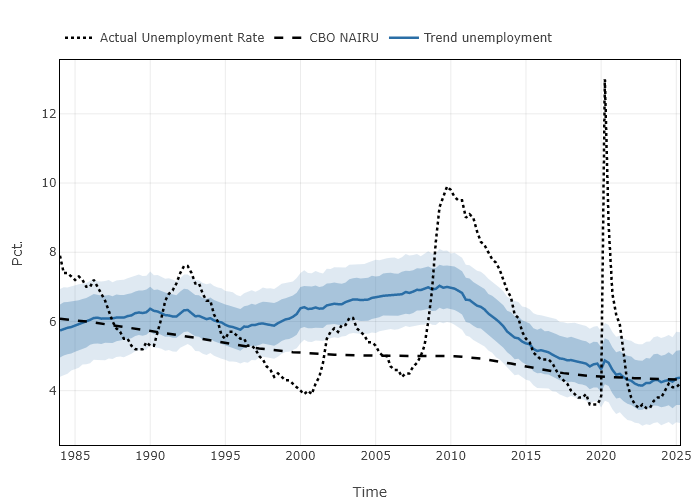

In [23]:
# potential employment vs cbo nairu
plt_nairu = Plot([
      # Efficient potential
        # 90% band: lower first (invisible), then upper filled to previous
        scatter(x=date, y=iT95[1:end-max_h, 3], mode="lines",
                line=attr(color="rgba(0,0,0,0)"), hoverinfo="skip", showlegend=false),
        scatter(x=date, y=iT05[1:end-max_h, 3], mode="lines", showlegend=false,
                fill="tonexty", fillcolor=band90_eff, line=attr(color="rgba(0,0,0,0)")),

        # 68% band: lower first (invisible), then upper filled to previous
        scatter(x=date, y=iT16[1:end-max_h, 3], mode="lines",
                line=attr(color="rgba(0,0,0,0)"), hoverinfo="skip", showlegend=false),
        scatter(x=date, y=iT84[1:end-max_h, 3], mode="lines", showlegend=false,
                fill="tonexty", fillcolor=band68_eff, line=attr(color="rgba(0,0,0,0)")),
        # Median line
        scatter(x=date, y=iTᵐ[1:end-max_h, 3], mode="lines", name="Trend unemployment", legendrank=1,
                line=attr(color=eff_color, width=2.5)),

        # CBO nairu
        scatter(x=date, y=cbo_nairu, line=attr(width=2.5, color="#000000", dash="dash"), name="CBO NAIRU"),

        # actual unemployment rate
        scatter(x=date, y=data[1:end-max_h, 3], line=attr(width=2.5, color="#000000", dash="dot"), name="Actual Unemployment Rate"),
],
base_layout)
PlotlyKaleido.savefig(plt_nairu, "$(results_folder)/trend_unemployment_vs_CBO_NAIRU.png")
display("image/png",read("$(results_folder)/trend_unemployment_vs_CBO_NAIRU.png"))




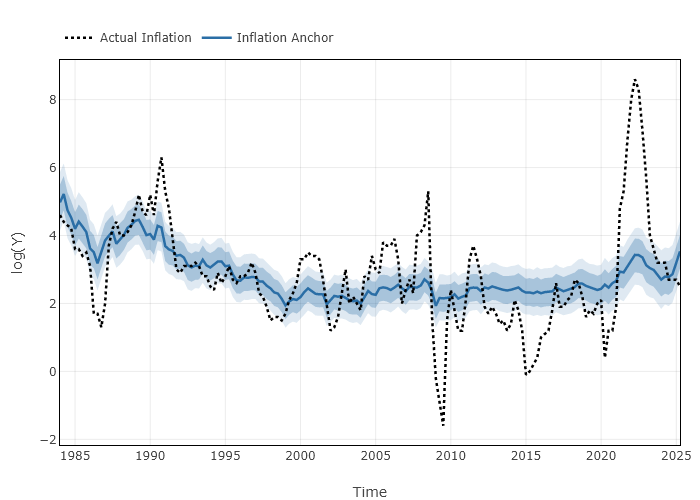

In [24]:
# observed inflation vs inflation trend

plt_inflation = Plot([
        # inflation trend
        # 90% band: lower first (invisible), then upper filled to previous
        scatter(x=date, y=T95[1:end-max_h, 4], mode="lines",
                line=attr(color="rgba(0,0,0,0)"), hoverinfo="skip", showlegend=false),
        scatter(x=date, y=T05[1:end-max_h, 4], mode="lines", showlegend=false,
                fill="tonexty", fillcolor=band90_eff, line=attr(color="rgba(0,0,0,0)")),

        # 68% band: lower first (invisible), then upper filled to previous
        scatter(x=date, y=T16[1:end-max_h, 4], mode="lines",
                line=attr(color="rgba(0,0,0,0)"), hoverinfo="skip", showlegend=false),
        scatter(x=date, y=T84[1:end-max_h, 4], mode="lines", showlegend=false,
                fill="tonexty", fillcolor=band68_eff, line=attr(color="rgba(0,0,0,0)")),
        # Median line
        scatter(x=date, y=Tᵐ[1:end-max_h, 4], mode="lines", name="Inflation Anchor", legendrank=1,
                line=attr(color=eff_color, width=2.5)),

        # actual inflation
        scatter(x=date, y=data[1:end-max_h, 4], line=attr(width=2.5, color="#000000", dash="dot"), name="Actual Inflation"),

        # # spf inflation
        # scatter(x=date, y=data[1:end-max_h,5], line=attr(width=2.5, color="#000000", dash="dash"), name="SPF Inflation"),

        # # uom inflation
        # scatter(x=date, y=data[1:end-max_h,6], line=attr(width=2.5, color="#000000", dash="dashdot"), name="UoM Inflation"),
],
Layout(
    template="plotly_white", hovermode="x unified",
    width=900, height=420, margin=attr(l=60, r=20, t=60, b=55),
    xaxis=attr(
        title="Time", showgrid=true, gridcolor="rgba(0,0,0,0.08)",
        zeroline=false, showline=true, linecolor="black", linewidth=1, mirror=true
    ),
    yaxis=attr(
        title="log(Y)", showgrid=true, gridcolor="rgba(0,0,0,0.08)",
        zeroline=false, showline=true, linecolor="black", linewidth=1, mirror=true,
        # range=[y_lims...]    # comment this line out to auto-scale
    ),
    legend=attr(orientation="h", x=0.0, y=1.02, yanchor="bottom", bgcolor="rgba(0,0,0,0)")))
PlotlyKaleido.savefig(plt_inflation, "$(results_folder)/inflation_trend_vs_actual.png")
display("image/png",read("$(results_folder)/inflation_trend_vs_actual.png"))